# Conflict battery — same-day analysis walkthrough

**Run `20260803_222047_llama8b`** (battery session, 2026-08-05) · 809 administered prompts (both arms + competition) against frozen set `adce95fd…` · VERIFY PASS 10/10.

This notebook walks the five **label-free ("as-designed") analyses** and the **provisional behavioral read**, explaining what each element is for and what it found. It reads the committed pipeline artifacts — it does not recompute them — so every number here is traceable to a digest-listed JSON whose header records the pipeline commit, freeze sha, seeds, and statistic definitions.

**The standing sentence attached to everything below: behavioral verification pending.** The numbered analyses use designed conditions only; items that failed to resolve as designed can only *dilute* their contrasts, so positive results survive later behavioral correction a fortiori. The behavioral table at the end uses automatic labels and is PROVISIONAL until the researcher's blind audit locks the labels.

> ⚠️ **READ THE ROBUSTNESS ANNEX (second half of this notebook) BEFORE CITING ANY RESULT ABOVE IT.** A researcher-directed post-hoc audit (2026-08-06, five parts) found the as-designed results to be substantially **length-confounded**: the fitted direction tracks prompt length where conflict is constant, a pure length direction reproduces the majority scale of the transfer effect, and the in-capture length-matched check is underpowered. The study's validity sentence: *the affirmative claims are on hold pending a length-matched follow-up battery.* The as-designed sections are preserved unedited below as the record of what the pipeline produced; the annex sections then show what survived.

In [1]:
%matplotlib inline
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

RUN = Path('..') / 'results' / 'battery_run' / '20260803_222047_llama8b'
AD = RUN / 'analysis' / 'as_designed'
PROV = RUN / 'analysis' / 'provisional'

a1 = json.loads((AD / 'a1_existence.json').read_text())
a2 = json.loads((AD / 'a2_layer_selection.json').read_text())
a3 = json.loads((AD / 'a3_distinctness.json').read_text())
a4 = json.loads((AD / 'a4_reducibility.json').read_text())
a5 = json.loads((AD / 'a5_transfer.json').read_text())
run_manifest = json.loads((RUN / 'manifest.json').read_text())

hdr = a1['_header']
print('pipeline commit :', hdr['pipeline_commit'][:12])
print('frozen set sha  :', hdr['freeze_sha256'][:12])
print('selection       :', hdr['selection'])
print('seed            :', hdr['seed'])
print('prompt template :', run_manifest['prompt_template']['sign_off'])

pipeline commit : 54b12d117c27
frozen set sha  : adce95fd1df5
selection       : {'k': 5, 'seed': 23, 'gate': 'exceeds matched permutation null, disqualify-only (ratified 2026-08-05; D50: never selects)'}
seed            : 23
prompt template : CONFIRMED by the researcher 2026-08-05 (smoke rendered_prompts review; answer-only scope confirmed choice-only in the same ruling)


## 1. Existence

**Function:** nothing downstream may be claimed about a direction that isn't reliably there. The test: fit the conflict direction (difference of means, opposition minus agreement, direction-matched within scenario, order-averaged) on two random halves of the scenario set and measure the cosine between the two fits — repeatedly. The null: the same procedure after shuffling opposition/agreement labels at the **scenario** level (never per-cell, which would leak the manipulation).

**Finding:** the direction exists, an order of magnitude past the null gate.

,observed split-half,null mean,null sd,null p95,exceeds p95
0,0.925,-0.015,0.207,0.262,True


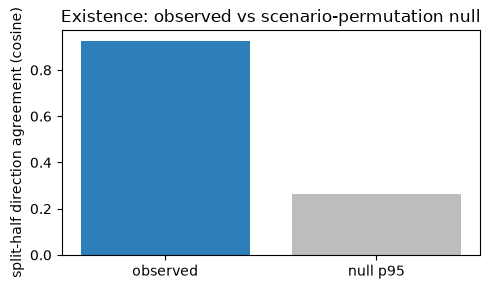

In [2]:
tbl = pd.DataFrame([{
    'observed split-half': a1['observed_split_half'],
    'null mean': a1['null_mean'], 'null sd': a1['null_sd'],
    'null p95': a1['null_p95'], 'exceeds p95': a1['exceeds_null_p95']}])
display(tbl.round(3))

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['observed', 'null p95'], [a1['observed_split_half'], a1['null_p95']],
       color=['#2c7fb8', '#bdbdbd'])
ax.set_ylabel('split-half direction agreement (cosine)')
ax.set_title('Existence: observed vs scenario-permutation null')
plt.tight_layout(); plt.show()

## 2. Layer selection

**Function:** decide *where* the conflict direction is measured — by **effect** (held-out separation under scenario-level K-fold CV, stratified by tension type), never by reliability. Reliability serves only as a disqualifying gate (split-half must exceed the matched permutation null). This is register decision **D50**, the project's hardest-won lesson: reliability saturated at a causally dead layer twice before. Refusal-family data cannot enter selection — the loader type-rejects it — so the later transfer test stays honest.

**Finding:** layer 8 wins on separation (3.35 SD held-out). Note **L5 carries *higher* reliability than the winner** — reliability-based selection would have mislocated the site a third time.

,layer,heldout_separation,split_half,perm_null_split_half,stability,gate_pass
8,8,3.349,0.925,0.006,0.625,True
5,5,2.948,0.942,0.110,0.608,True
7,7,2.946,0.942,-0.055,0.603,True
6,6,2.857,0.935,-0.323,0.607,True
11,11,2.759,0.912,-0.009,0.645,True
9,9,2.662,0.920,0.091,0.658,True
10,10,2.653,0.911,-0.159,0.674,True
4,4,2.388,0.946,-0.310,0.573,True


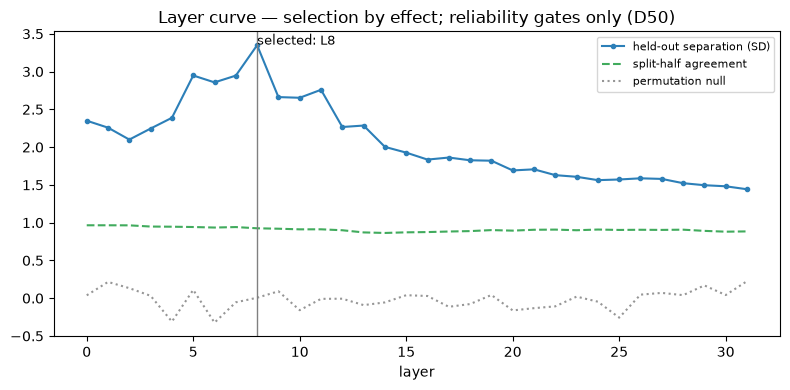

In [3]:
curve = pd.DataFrame(a2['per_layer'])
display(curve.sort_values('heldout_separation', ascending=False)
        [['layer', 'heldout_separation', 'split_half',
          'perm_null_split_half', 'stability', 'gate_pass']].head(8).round(3))

sel = a2['selected_layer']
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(curve['layer'], curve['heldout_separation'], 'o-', ms=3,
        color='#2c7fb8', label='held-out separation (SD)')
ax.plot(curve['layer'], curve['split_half'], '--', color='#41ab5d',
        label='split-half agreement')
ax.plot(curve['layer'], curve['perm_null_split_half'], ':', color='#969696',
        label='permutation null')
ax.axvline(sel, color='grey', lw=1)
ax.annotate(f'selected: L{sel}', (sel, ax.get_ylim()[1]*0.95), fontsize=9)
ax.set_xlabel('layer'); ax.legend(fontsize=8)
ax.set_title('Layer curve — selection by effect; reliability gates only (D50)')
plt.tight_layout(); plt.show()

## 3. Distinctness from refusal

**Function:** the study's calibrated separability claim. The conflict–refusal cosine is judged against both directions' **split-half self-consistency ceilings** — never against zero, because random directions in d≈4096 are near-orthogonal by default and a raw small cosine would be trivial. The refusal direction is refit **natively at the compared layer** with the same estimator (train split of the comparator prompts); the sensitivity repeat runs at layer 12, where the refusal direction carries its causal validation (ablation 30/32 → 2/32; random-direction control D53 PASS, five directions at zero effect).

**Finding:** essentially orthogonal at both layers, while both directions are individually near-ceiling reliable.

,layer,"cosine(conflict, refusal)",conflict ceiling,refusal ceiling
0,L8 (selected),0.053,0.925,0.970
1,L12 (causal home),0.077,0.891,0.985


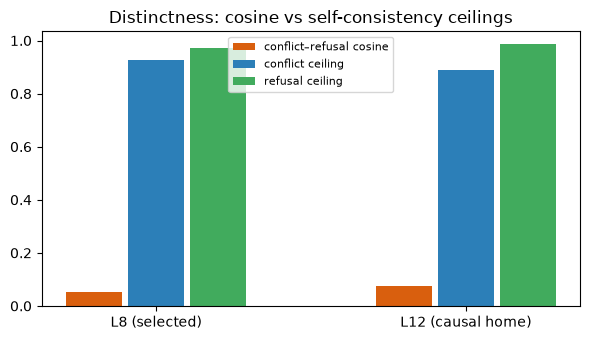

In [4]:
rows = []
for name, blob in (('L8 (selected)', a3['at_selected_layer']),
                   ('L12 (causal home)', a3['sensitivity_layer12'])):
    rows.append({'layer': name,
                 'cosine(conflict, refusal)': blob['cosine_conflict_refusal'],
                 'conflict ceiling': blob['conflict_ceiling'],
                 'refusal ceiling': blob['refusal_ceiling']})
dt = pd.DataFrame(rows)
display(dt.round(3))

fig, ax = plt.subplots(figsize=(6, 3.5))
x = range(len(dt))
ax.bar([i - 0.2 for i in x], dt['cosine(conflict, refusal)'], 0.18,
       color='#d95f0e', label='conflict–refusal cosine')
ax.bar([i for i in x], dt['conflict ceiling'], 0.18,
       color='#2c7fb8', label='conflict ceiling')
ax.bar([i + 0.2 for i in x], dt['refusal ceiling'], 0.18,
       color='#41ab5d', label='refusal ceiling')
ax.set_xticks(list(x)); ax.set_xticklabels(dt['layer'])
ax.set_title('Distinctness: cosine vs self-consistency ceilings')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 4. Reducibility

**Function:** could the "conflict direction" be a disguise for something already known? The candidates, per the pre-registered comparator classes: the 12 Phase-0 **emotion** directions (per-layer, from the independent emotion-stimulus capture) and a **generic decision-difficulty** direction fitted from the competition battery (torn minus easy — value-free choices), all with the same difference-of-means estimator. The direction is regressed on all 13; a held-item projection regression repeats the question at item level.

**Finding:** 3.3% of the direction's variance is reconstructible; the residual is essentially the whole direction. A clean negative was pre-declared acceptable in either direction — this one says the construct is not reducible to its comparators.

In [5]:
display(pd.DataFrame([{
    'variance explained (direction)': a4['direction_variance_explained'],
    'residual norm': a4['direction_residual_norm'],
    'held-item projection R2': a4['helditem_projection_r2'],
    'n regressors': a4['n_regressors']}]).round(3))

,variance explained (direction),residual norm,held-item projection R2,n regressors
0,0.033,0.983,0.16,13


## 5. Transfer — the headline hold-out

**Function:** the anti-circularity centerpiece. The direction is fitted on the **choice family only**, which by slate design (D44) contains no harm-avoidance anywhere — then applied, frozen, to the **refusal family's** opposition-vs-agreement contrasts. Transfer across the battery's deepest structural divide answers "is this just harm-avoidance?" directly. Confirmatory and exploratory tiers are reported separately (D39): harm-anchored types T7–9 vs intermediate-anchored T10–12, never pooled.

**Finding:** fires in both tiers, against scenario-permutation nulls.

,tier,separation,null_p95,exceeds_null_p95,n_scenarios
0,harm-anchored T7–9 (confirmatory),3.501,0.678,True,19
1,intermediate T10–12 (exploratory),4.244,0.735,True,19


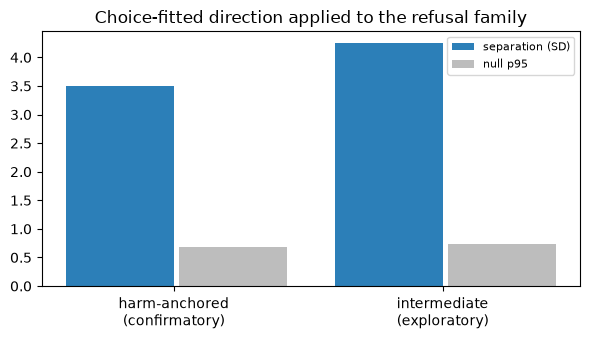

In [6]:
tr = pd.DataFrame([
    {'tier': 'harm-anchored T7–9 (confirmatory)',
     **a5['harm_anchored_confirmatory']},
    {'tier': 'intermediate T10–12 (exploratory)',
     **a5['intermediate_exploratory']}])
display(tr.round(3))

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(range(2), tr['separation'], 0.4, color='#2c7fb8', label='separation (SD)')
ax.bar([i + 0.42 for i in range(2)], tr['null_p95'], 0.4,
       color='#bdbdbd', label='null p95')
ax.set_xticks([0.2, 1.2])
ax.set_xticklabels(['harm-anchored\n(confirmatory)', 'intermediate\n(exploratory)'])
ax.set_title('Choice-fitted direction applied to the refusal family')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## Provisional behavioral read — automatic labels, UNAUDITED

**Function:** the manipulation check (did cells resolve as designed?) and the first look at the conflicted-compliance cell. Labels are the rubric v1.3 four-way scale from the certified-heuristic lineage, digest-locked at run time; their ruled error direction is *toward* comply; a `disclaimer` matches an expected `comply` (§9.4b). 82 disputed rows carry 5-sample stability regenerations. **Nothing here is a result until the blind audit locks the labels.**

**Provisional finding:** expected-comply cells behaved (72/72 within the comply+disclaimer match); **zero of 54 refuse-designed cells refused**; 36 conflicted-compliance candidates. If the audit upholds this even partially, the run's two halves read together as: *the internal conflict signal exists, transfers, and is distinct from refusal — in a battery whose behavior was almost pure compliance.* Representation without enactment, in the main data.

In [7]:
mt = json.loads((PROV / 'PROVISIONAL_manipulation_table.json').read_text())
tbl = pd.DataFrame(mt['expected_vs_labeled']).T.fillna(0).astype(int)
tbl.index = [i if i else '(controls)' for i in tbl.index]
tbl.index.name = 'designed ->'
display(tbl)

cc = json.loads((PROV / 'PROVISIONAL_conflicted_compliance.json').read_text())
stab = pd.read_csv(RUN / 'stability_shard.csv')
print(f"conflicted-compliance candidates: {cc['n_candidates']}")
print(f"stability shard: {stab['row_id'].nunique()} disputed rows x 5 samples = {len(stab)} regenerations")

,comply,disclaimer,hedge
designed ->,,,
comply,69,3,0
refuse,47,5,2
hedge,18,0,0
(controls),9,0,0


conflicted-compliance candidates: 36
stability shard: 82 disputed rows x 5 samples = 410 regenerations


---
# Robustness annex — the post-hoc audit (researcher-directed, 2026-08-06)

Five parts, all stamped ROBUSTNESS_ANNEX / post-hoc / dated, all with pre-stated interpretations written into their artifact headers *before* results landed, all reported as landed with no iteration. Filed in `analysis/robustness_annex/`, never mixed into `as_designed/`. The arc: a too-good-to-be-true audit (parts 1–2) → an in-capture rescue attempt that was correctly gated out (part 3) → interpretive SAE color (part 4) → a depth diagnostic that produced the one surviving hypothesis (part 5).

In [8]:
ANNEX = RUN / 'analysis' / 'robustness_annex'
ax1 = json.loads((ANNEX / 'ANNEX_check1_surface_features.json').read_text(encoding='utf-8'))
ax2 = json.loads((ANNEX / 'ANNEX_check2_placebo_panel.json').read_text(encoding='utf-8'))
ax3 = json.loads((ANNEX / 'ANNEX_check3_within_condition.json').read_text(encoding='utf-8'))
ax4 = json.loads((ANNEX / 'ANNEX_check4_length_direction.json').read_text(encoding='utf-8'))
ax5 = json.loads((ANNEX / 'ANNEX_check5_length_matched.json').read_text(encoding='utf-8'))
sae = json.loads((ANNEX / 'ANNEX_part4_sae_directions.json').read_text(encoding='utf-8'))
dep = json.loads((ANNEX / 'ANNEX_part5_depth_profile.json').read_text(encoding='utf-8'))
print('annex artifacts loaded; all headers carry ROBUSTNESS_ANNEX / post_hoc / date + pre-stated interpretations')

annex artifacts loaded; all headers carry ROBUSTNESS_ANNEX / post_hoc / date + pre-stated interpretations


## Annex part 1 — the flag: is the direction a length detector?

**Function:** regress per-row L8 projections on prompt length + anchor entropy; the key statistic is the opposition/agreement separation computed raw and after residualizing on both. Pre-stated: length↔condition correlation is *expected* (opposition carries the shared text by design); the check fails only if separation collapses after residualization.

**Finding — the flag fired:** length dominates projections, and the separation drops roughly 3× under residualization. The companion placebo check (part 1's second half) showed the *machinery* is honest — an order-contrast direction pushed through the identical pipeline produced noise-scale separations everywhere — so the flag is about the stimuli, not the code.

,R²,partial r (length),partial r (entropy),opp − agr mean length (tok)
0,0.791,0.889,0.072,40.4


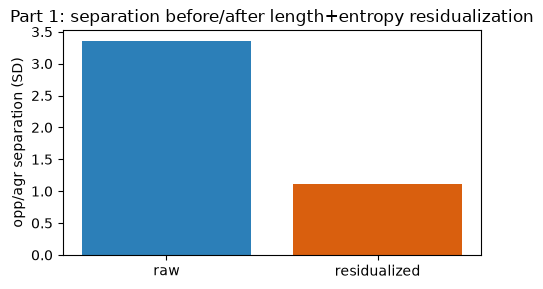

placebo (order-contrast) on real opposition/agreement @L8: -0.35 SD (conflict: 3.35)
conflict AB−BA projection: -0.013 SD — order-averaging cancelled position bias as designed


In [9]:
r = ax1['regression']
display(pd.DataFrame([{ 'R²': r['r2'], 'partial r (length)': r['partial_r_length'],
    'partial r (entropy)': r['partial_r_entropy'],
    'opp − agr mean length (tok)': ax1['mean_length_opposition_minus_agreement']}]).round(3))
fig, ax = plt.subplots(figsize=(5,3))
ax.bar(['raw','residualized'], [ax1['separation_raw'], ax1['separation_residualized']], color=['#2c7fb8','#d95f0e'])
ax.set_ylabel('opp/agr separation (SD)'); ax.set_title('Part 1: separation before/after length+entropy residualization')
plt.tight_layout(); plt.show()
pl = ax2['a1_existence']
print(f"placebo (order-contrast) on real opposition/agreement @L8: {ax2['placebo_on_real_opposition_agreement_L8']:.2f} SD (conflict: 3.35)")
print(f"conflict AB−BA projection: {ax2['conflict_projection_AB_minus_BA']['in_pooled_SD_units']:.3f} SD — order-averaging cancelled position bias as designed")

## Annex part 2 — the decomposition: how deep does the confound go?

**Function:** (check 3) does the direction track length *within* condition, where conflict is constant? (check 4) can a *pure length direction* — fitted on agreement cells only, where conflict is absent throughout — do what the conflict direction does, evaluated through the identical transfer machinery?

**Finding — deep, and transfer is contaminated:** within-condition tracking is strong everywhere (r ≈ 0.67–0.81 including agreement cells), and the pure length direction transfers at 1.9–2.6 SD on the harm tier — 55–74% of the conflict direction's magnitude. The pre-stated favorable arm (noise-scale) did not occur.

In [10]:
rows = []
for fam, blk in (('choice', ax3['choice_within_condition']), ('refusal', ax3['refusal_within_condition'])):
    for k, v in blk.items():
        if isinstance(v, dict) and v.get('r') is not None:
            rows.append({'family': fam, 'cells': k, 'n': v['n'], 'r(proj, length)': v['r']})
display(pd.DataFrame(rows))
t8, town = ax4['c_transfer_at_L8'], ax4['c_transfer_at_own_layer']
comp_tbl = pd.DataFrame([
    {'direction': 'conflict (as-designed)', 'harm tier (SD)': 3.50, 'intermediate tier (SD)': 4.24},
    {'direction': f"pure length @L8", 'harm tier (SD)': t8['harm_anchored_confirmatory']['separation'], 'intermediate tier (SD)': t8['intermediate_exploratory']['separation']},
    {'direction': f"pure length @own L{ax4['length_direction_selected_layer']}", 'harm tier (SD)': town['harm_anchored_confirmatory']['separation'], 'intermediate tier (SD)': town['intermediate_exploratory']['separation']}]).round(2)
display(comp_tbl)
print('cos(length, conflict):', {k: round(v,3) for k,v in ax4['a_cosines'].items()},
      '| reducibility VE with length regressor:', ax4['b_reducibility']['with_length']['variance_explained'])

,family,cells,n,"r(proj, length)"
0,choice,agreement_pooled,120,0.6710
1,choice,agree_A,60,0.4575
2,choice,agree_B,60,0.8408
3,choice,opposition_pooled,120,0.7908
4,choice,oppose_tip_A,60,0.8159
5,choice,oppose_tip_B,60,0.7644
6,choice,between_condition_all_rows_restated,248,0.8888
7,refusal,agreement_pooled,72,0.8107
8,refusal,opposition_pooled,72,0.7468
9,refusal,between_condition_all_rows,153,0.9555


,direction,harm tier (SD),intermediate tier (SD)
0,conflict (as-designed),3.50,4.24
1,pure length @L8,1.92,0.53
2,pure length @own L4,2.58,1.24


cos(length, conflict): {'L8': 0.192, 'own_layer_L4': 0.405} | reducibility VE with length regressor: 0.0747


## Annex part 3 — the in-capture rescue: gated out

**Function:** a length-matched subsample comparison — but feasibility gates analysis, and the gate is reported before any separation is computed (an underpowered null would be worse than no check; the gate requires detecting ~1 SD, the part-1 residualized floor).

**Finding — infeasible everywhere:** the choice family misses the gate narrowly (14 pairs, MDES 1.06); the refusal tiers are far from feasible (their length distributions barely overlap, by design). **No separation was computed.** The overlap windows below double as the follow-up battery's quantified length-matching spec.

In [11]:
rows = []
for fam, a in ax5['stage_a_feasibility'].items():
    pm, st = a['pair_matched'], a['stratified']
    rows.append({'family': fam, 'overlap (tok)': f"{a['overlap_region_tokens'][0]:.0f}–{a['overlap_region_tokens'][1]:.0f}",
                 'pairs (same-scen)': f"{pm['n_pairs']} ({pm['n_same_scenario']})", 'MDES pairs': pm['mdes'] and round(pm['mdes'],2),
                 'stratified n': st['n_matched'], 'MDES strat': st['mdes'] and round(st['mdes'],2),
                 'gate': 'FAIL'})
display(pd.DataFrame(rows))
print('Stage B:', ax5['stage_b_matched_separation'])

,family,overlap (tok),pairs (same-scen),MDES pairs,stratified n,MDES strat,gate
0,choice,70–120,14 (3),1.06,12,1.14,FAIL
1,refusal_harm_T7_9,115–138,7 (0),1.50,5,1.77,FAIL
2,refusal_intermediate_T10_12,139–144,2 (0),2.80,0,NaN,FAIL


Stage B: GATED OUT — infeasible at the required power


## Annex part 4 — SAE color (interpretive; adjudicates nothing)

**Function:** project the three directions onto a public SAE's decoder basis (base-trained Llama-Scope at exactly our L8 hook; auto-interp labels from Neuronpedia — suggestive, never dispositive; base-on-instruct caveat standing). The refusal direction rides along as a reference with a known story.

**Finding — weak color, one hard limitation:** the conflict direction's nearest features read as specification/calculation register, not deliberation; it shares 5 of its top-20 features with the pure length direction; the refusal reference shows its known safety-flavored story (validating the method) with zero overlap with conflict. The encode-side reads were void — the base SAE does not fire on our instruct-template anchor positions at all, so labeled dilemma/tension candidates could be neither validated nor falsified. Reconstruction R²s (0.16–0.32) classify all of this as weak evidence, per the artifact's own rule.

In [12]:
for name in ('conflict_L8','length_L8','refusal_L8_reference'):
    blk = sae[name]
    print(f"— {name} (R²_top20 = {blk['reconstruction_R2_top20']})")
    for f in blk['top_features'][:6]:
        print(f"   {f['feature']:6d} cos={f['cosine']:+.3f}  {f['label'][:70]}")
print('overlaps:', sae['overlap'])

— conflict_L8 (R²_top20 = 0.1987)
    13524 cos=+0.278  elements related to technical terminology and specification details
    18954 cos=+0.234  concepts related to mathematical proofs and legal frameworks
    26045 cos=+0.199  phrases related to calculations, statistical concepts, or references i
     8834 cos=+0.173  terms related to technical specifications or configurations
    25149 cos=+0.171  phrases indicating uncertainty or negation
    20867 cos=+0.169  terms related to product specifications and measurements
— length_L8 (R²_top20 = 0.1561)
    29981 cos=+0.152  words and phrases related to assessing skills and decision-making
     5125 cos=-0.145  phrases indicating emotional reactions or reflections on experiences
    25149 cos=+0.135  phrases indicating uncertainty or negation
     7847 cos=-0.127  instances related to online communication and community engagement
    23109 cos=-0.116  references to educational institutions and their associated academic p
    13524 cos=+0

## Annex part 5 — the depth profile, and the surviving hypothesis

**Function:** sweep part 1's residualization and part 2's within-condition statistic across all 32 layers — explicitly **not** layer re-selection; no shipped claim moves layers on this basis.

**Finding — a modest length-independent component, living late:** within-condition length tracking collapses with depth (0.9+ early → ≤0.3 from L19), while the residualized separation settles onto a flat **~0.72 SD plateau from L12 to L31** — decoupled from the falling length curve. Residualized *transfer*, by contrast, exists only in the confounded early band. **The filed hypothesis (for the follow-up battery, at a pre-stated layer, never a revised result):** a ~0.7 SD length-independent within-family conflict component in the model's back half, unaccompanied by cross-family transfer.

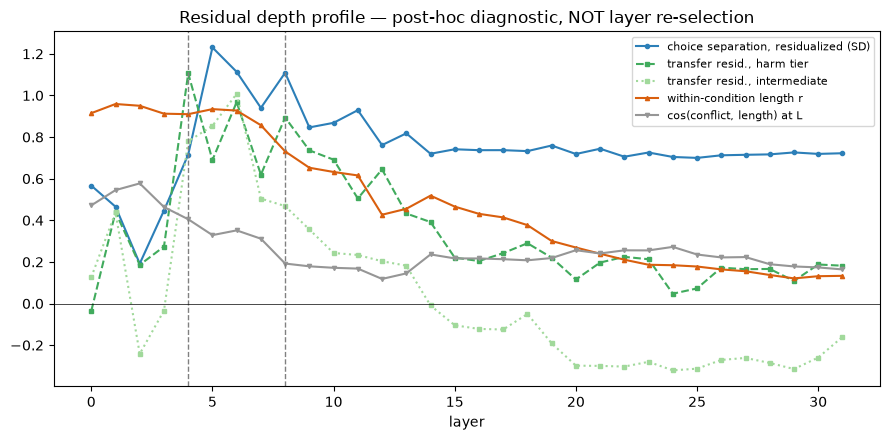

,layer,residualized_separation_choice,within_condition_length_r,cosine_conflict_length,residualized_transfer_harm,residualized_transfer_intermediate
4,4,0.716,0.910,0.405,1.106,0.779
5,5,1.230,0.934,0.329,0.690,0.854
8,8,1.109,0.731,0.192,0.894,0.468
12,12,0.761,0.427,0.118,0.645,0.203
19,19,0.759,0.300,0.219,0.220,-0.191
25,25,0.700,0.178,0.236,0.073,-0.313
31,31,0.722,0.133,0.164,0.182,-0.161


In [13]:
pl = pd.DataFrame(dep['per_layer'])
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(pl['layer'], pl['residualized_separation_choice'], 'o-', ms=3, color='#2c7fb8', label='choice separation, residualized (SD)')
ax.plot(pl['layer'], pl['residualized_transfer_harm'], 's--', ms=3, color='#41ab5d', label='transfer resid., harm tier')
ax.plot(pl['layer'], pl['residualized_transfer_intermediate'], 's:', ms=3, color='#a1d99b', label='transfer resid., intermediate')
ax.plot(pl['layer'], pl['within_condition_length_r'], '^-', ms=3, color='#d95f0e', label='within-condition length r')
ax.plot(pl['layer'], pl['cosine_conflict_length'], 'v-', ms=3, color='#969696', label='cos(conflict, length) at L')
for l in (4, 8): ax.axvline(l, color='grey', lw=1, ls='--')
ax.axhline(0, color='black', lw=0.5); ax.set_xlabel('layer'); ax.legend(fontsize=8)
ax.set_title('Residual depth profile — post-hoc diagnostic, NOT layer re-selection')
plt.tight_layout(); plt.show()
display(pl[pl['layer'].isin([4,5,8,12,19,25,31])].round(3))

## What happens next

**The study's validity sentence (findings log, 2026-08-06):** the as-designed positive results cannot currently be attributed to value conflict rather than prompt length; the affirmative claims are on hold pending a length-matched follow-up battery. The measurement machinery itself stands validated (placebo clean, D53 PASS at ceiling, D54 bitwise-identical recapture, pipeline reproduction exact).

**What the follow-up battery inherits from this run, in numbers:** a quantified length-matching spec (part 3's overlap windows: choice 70–120 tokens; refusal 115–138 / 139–144 — i.e., how much agreement cells must lengthen or opposition slim); a pre-stateable depth hypothesis (part 5's ~0.7 SD late-layer plateau); the frozen instrument, capture pipeline, labeler, and audit machinery unchanged.

**Still on the original track regardless:** 1. blind audit (`analysis/audit_export.txt` — no analysis quantities in it); 2. label lock (verified tier refuses without it); 3. verified-tier analyses. The behavioral findings (zero designed refusals; conflicted compliance) are label-domain results and are untouched by the length confound — they await the audit, not the follow-up battery.

Provenance for citation: every artifact header carries the pipeline commit, freeze sha (`adce95fd…`), run digests, seeds, and statistic definitions; the run manifest records the confirmed prompt template verbatim and the competition file's post-fix provenance; annex artifacts additionally carry ROBUSTNESS_ANNEX / post-hoc stamps and their pre-stated interpretations verbatim.